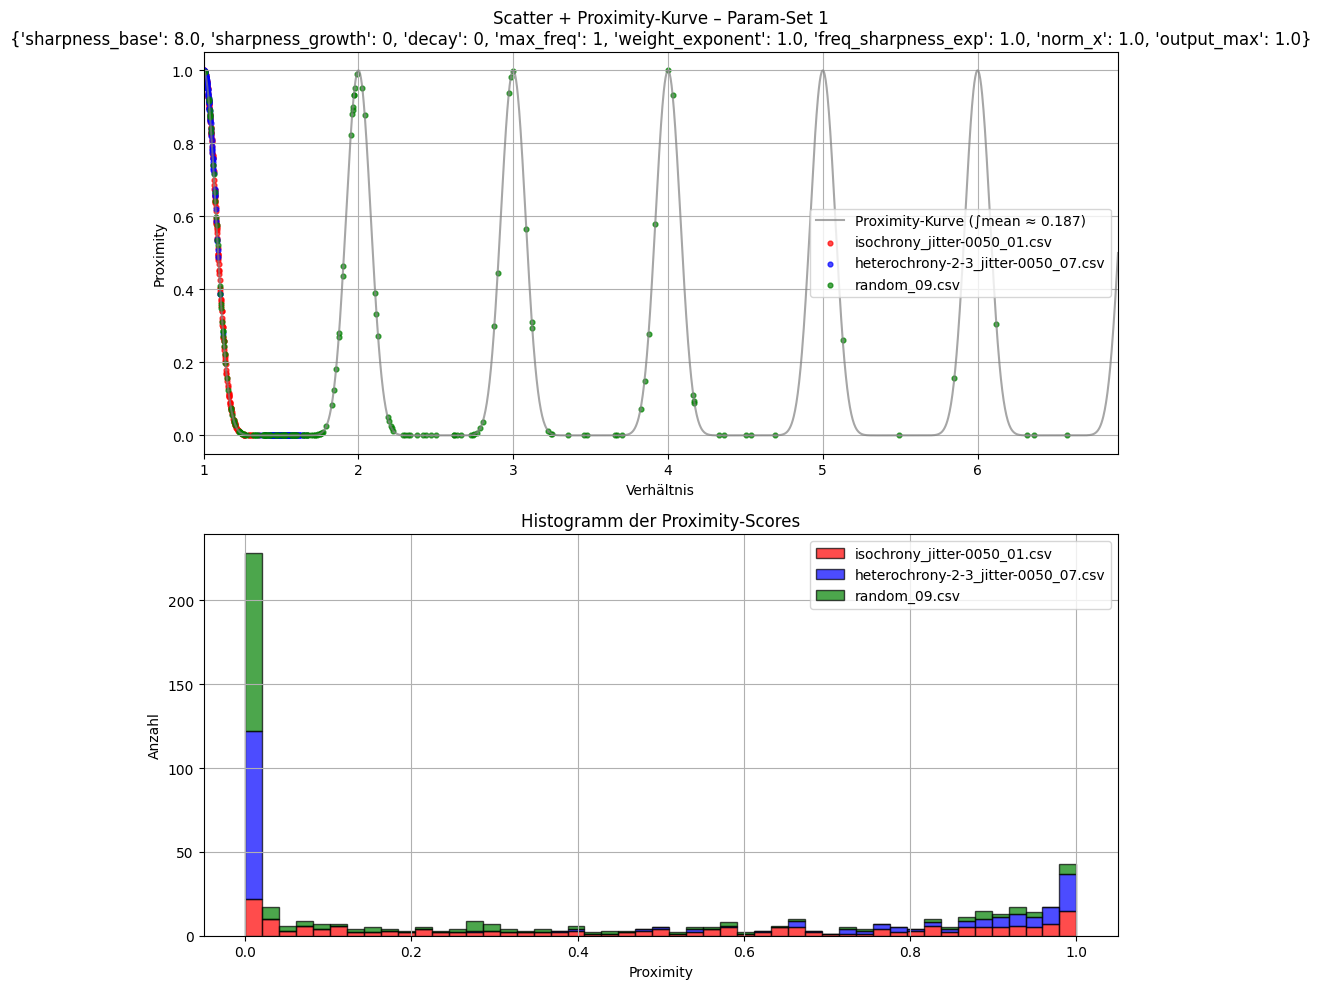

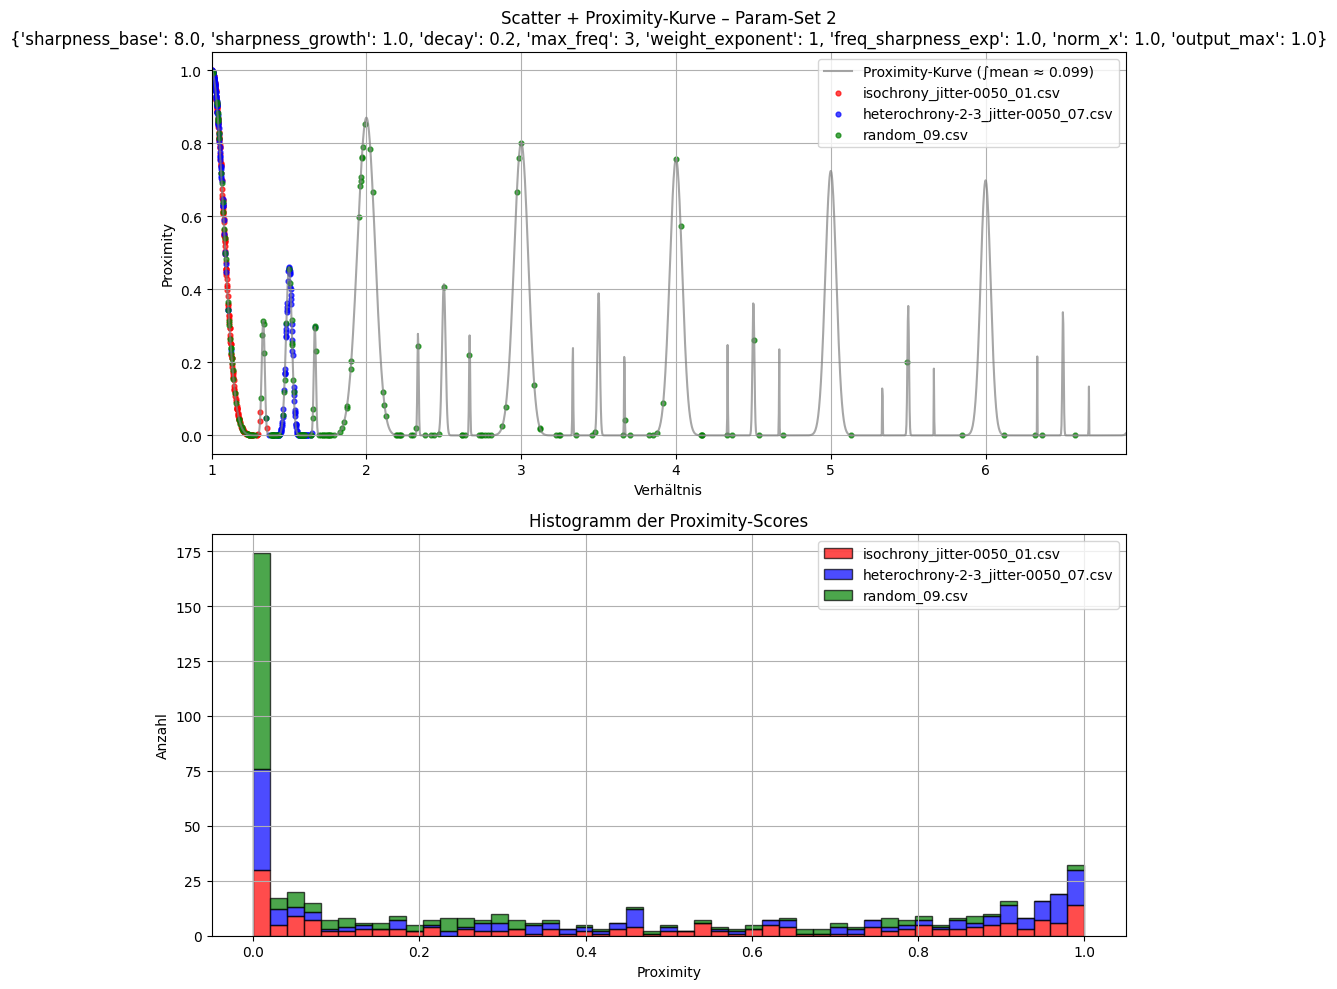

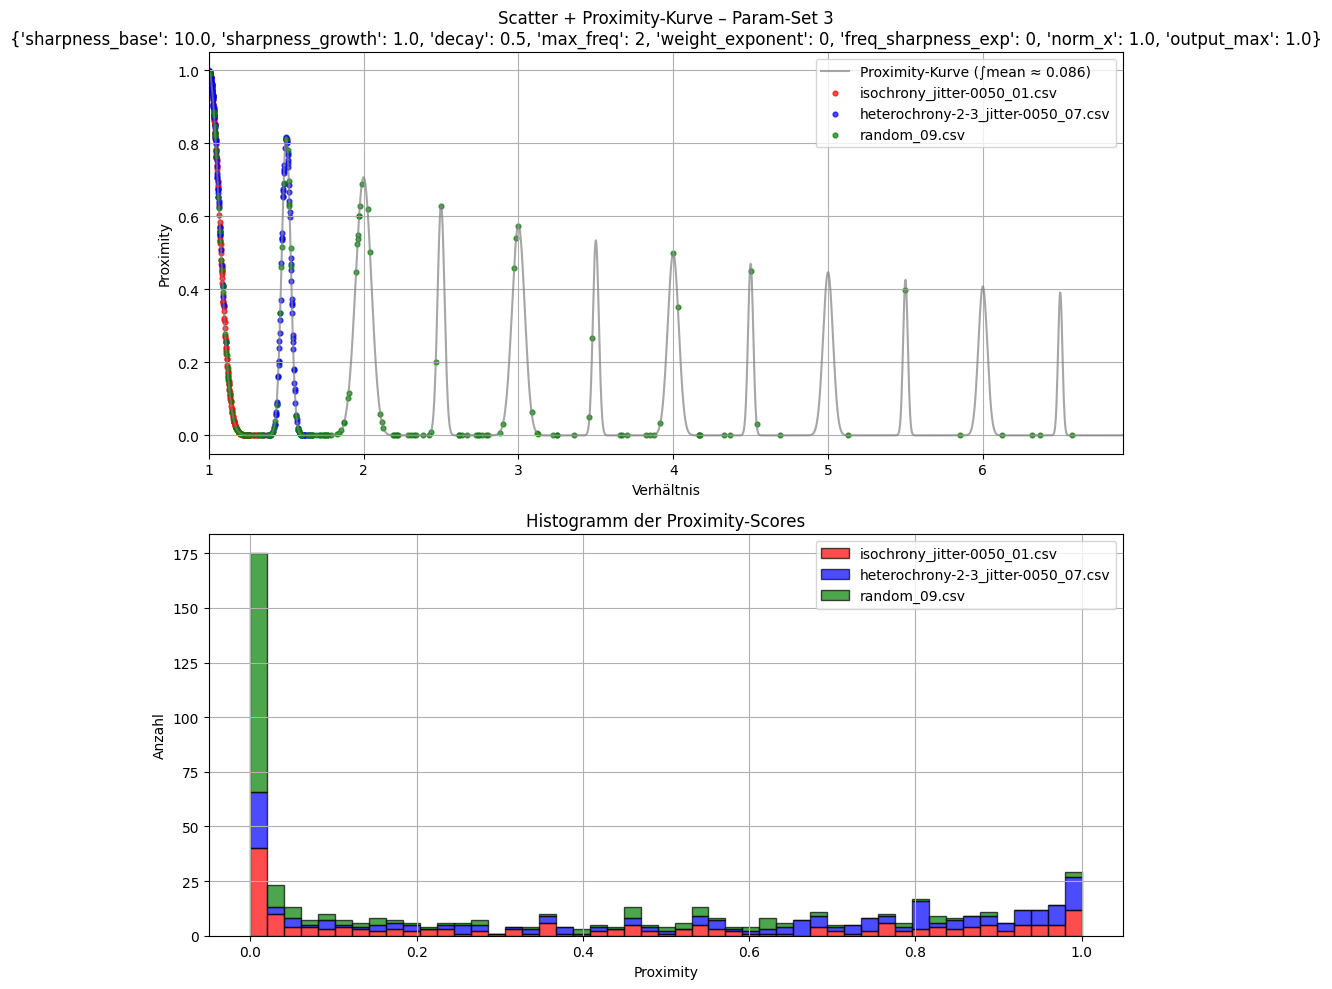

In [1]:
# ===============================================
# Analyse von IOI-Verhältnissen zur Beat-Detektion 
# Mehrere Parameter-Sets ausprobieren
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import simpson
from fractions import Fraction

# =============================
# 1) Proximity-Funktion
# =============================
def proximity_max_freq(
    x,
    sharpness_base=1.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_exp)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# =============================
# 2) Funktion für IOI-Paare
# =============================
def build_pairwise_proximity_df(iois, params, threshold=0.01):
    n = len(iois)
    ratios = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j]) 
                        for j in range(n)] for i in range(n)])
    prox_max, peak_idx, freqs = proximity_max_freq(ratios, **params)

    rows = []
    for i in range(n):
        for j in range(i + 1, n):
            r = float(ratios[i, j])
            s = float(prox_max[i, j])
            if s > threshold:
                best_f = int(freqs[peak_idx[i, j]])
                p = int(round(r * best_f))
                frac = Fraction(p, best_f)
                label = f"{frac.numerator}/{frac.denominator}"
            else:
                label = "Keine Proximity"

            rows.append({
                "i": i,
                "j": j,
                "ioi_i": float(iois[i]),
                "ioi_j": float(iois[j]),
                "ratio": r,
                "proximity": s,
                "peak_label": label
            })

    df_pairs = pd.DataFrame(rows)
    return df_pairs, ratios, prox_max

# =============================
# 3) Daten einlesen
# =============================
PAIR_THRESHOLD = 0.01
base_dir = Path("../data/theoretical_sequences/baseIOI-0.50/20beats/")
filenames = ["isochrony_jitter-0050_01.csv",
             "heterochrony-2-3_jitter-0050_07.csv",
             "random_09.csv"]
colors = ["red", "blue", "green"]

# =============================
# 4) Verschiedene Parameter-Sets definieren
# =============================
param_sets = [
    dict(sharpness_base=8.0, sharpness_growth=0, decay=0,
         max_freq=1, weight_exponent=1.0, freq_sharpness_exp=1.0,
         norm_x=1.0, output_max=1.0),

    dict(sharpness_base=8.0, sharpness_growth=1.0, decay=0.2,
         max_freq=3, weight_exponent=1, freq_sharpness_exp=1.0,
         norm_x=1.0, output_max=1.0),

    dict(sharpness_base=10.0, sharpness_growth=1.0, decay=0.5,
         max_freq=2, weight_exponent=0, freq_sharpness_exp=0,
         norm_x=1.0, output_max=1.0)
]

# =============================
# 5) Für jedes Param-Set analysieren & plotten
# =============================
for idx, params in enumerate(param_sets, start=1):
    dfs = []
    for fname in filenames:
        seq_path = base_dir / fname
        if not seq_path.exists():
            raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")
        df = pd.read_csv(seq_path)
        iois = df["IOI"].dropna().values
        df_pairs, ratios, prox_max = build_pairwise_proximity_df(iois, params, threshold=PAIR_THRESHOLD)
        df_pairs["source"] = fname
        dfs.append(df_pairs)

    df_all = pd.concat(dfs, ignore_index=True)

    # Plots
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    # --- Scatter + Proximity-Kurve ---
    x_min = max(1.0, df_all["ratio"].min() * 0.95)
    x_max = df_all["ratio"].max() * 1.05
    x_range = np.linspace(x_min, x_max, 2000)
    y_curve = np.array([proximity_max_freq(x, **params)[0] for x in x_range])
    mean_prox = simpson(y_curve, x=x_range) / (x_range[-1] - x_range[0])

    axes[0].plot(x_range, y_curve,
                 label=f"Proximity-Kurve (∫mean ≈ {mean_prox:.3f})",
                 alpha=0.7, color="gray")

    for fname, color in zip(filenames, colors):
        df_seq = df_all[df_all["source"] == fname]
        axes[0].scatter(df_seq["ratio"], df_seq["proximity"],
                        s=12, alpha=0.7, color=color, label=f"{fname}")

    axes[0].set_title(f"Scatter + Proximity-Kurve – Param-Set {idx}\n{params}")
    axes[0].set_xlabel("Verhältnis")
    axes[0].set_ylabel("Proximity")
    axes[0].set_xlim(x_min, x_max)
    axes[0].legend()
    axes[0].grid(True)

    # --- Histogramm ---
    bins = np.linspace(0, 1, 50)
    axes[1].hist(
        [df_all[df_all["source"] == fname]["proximity"].values for fname in filenames],
        bins=bins, stacked=True,
        label=filenames, color=colors,
        alpha=0.7, edgecolor="black"
    )
    axes[1].set_title("Histogramm der Proximity-Scores")
    axes[1].set_xlabel("Proximity")
    axes[1].set_ylabel("Anzahl")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

